#  Workshop bk

NAMA : ROZAQ LEKSONO

NIM : A11.2021.13700


### Table of Contents
* [1. Pengumpulan Data](#h1)
* [2. Menelaah Data](#h2)
* [3. Validasi Data](#h3)
* [4. Menentukan Object Data](#h4)
* [5. Membersihkan Data](#h5)
* [6. Konstruksi Data](#h6)
* [7. Menentukan Label Data](#h7)
* [8. Membangun dan Mengevaluasi Model](#h8)
* [9. Komparasi Model](#h9)


Dataset yang digunakan diambil dari sumber berikut: https://archive.ics.uci.edu/dataset/82/post+operative+patient.

The classification task of this database is to determine where patients in a postoperative recovery area should be sent to next.  Because hypothermia is a significant concern after surgery (Woolery, L. et. al. 1991), the attributes correspond roughly to body temperature measurements.

Fitur-fitur dalam dataset meliputi:
   1. L-CORE (patient's internal temperature in C):
              high (> 37), mid (>= 36 and <= 37), low (< 36)
     2. L-SURF (patient's surface temperature in C):
              high (> 36.5), mid (>= 36.5 and <= 35), low (< 35)
     3. L-O2 (oxygen saturation in %):
              excellent (>= 98), good (>= 90 and < 98),
              fair (>= 80 and < 90), poor (< 80)
     4. L-BP (last measurement of blood pressure):
              high (> 130/90), mid (<= 130/90 and >= 90/70), low (< 90/70)
     5. SURF-STBL (stability of patient's surface temperature):
              stable, mod-stable, unstable
     6. CORE-STBL (stability of patient's core temperature)
              stable, mod-stable, unstable
     7. BP-STBL (stability of patient's blood pressure)
              stable, mod-stable, unstable
     8. COMFORT (patient's perceived comfort at discharge, measured as
              an integer between 0 and 20)
     9. decision ADM-DECS (discharge decision):
              I (patient sent to Intensive Care Unit),
              S (patient prepared to go home),
              A (patient sent to general hospital floor)

Target dalam klasifikasi ini adalah atribut ADM-DECS,
A discharge decision: I (patient sent to Intensive Care Unit), S (patient prepared to go home), A (patient sent to general hospital floor)

# 1.) Pengumpulan Data


## Import Library

In [ ]:
# Import library yang diperlukan
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
# pip install ucimlrepo

## soal no 1 Load Dataset
Metode:
1. Load langsung di workspace Google Colab
2. Load dari Google Drive

Pada notebook ini kita menggunakan metode load langsung di workspace Google Colab

In [ ]:
# # Buat akses dari google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Baca dataset menggunakan library pandas dan masukkan ke sebuah variabel (misalnya df)
df = pd.read_csv('/content/post-operative-new.data')
# df.info()
# Tampilkan 5 data teratas dari dataset
df.head()

,0,mid,low,excellent,mid.1,stable,stable.1,stable.2,15,A
0,1,mid,high,excellent,high,stable,stable,stable,10,S
1,2,high,low,excellent,high,stable,stable,mod-stable,10,A
2,3,mid,low,good,high,stable,unstable,mod-stable,15,A
3,4,mid,mid,excellent,high,stable,stable,stable,10,A
4,5,high,low,good,mid,NaN,stable,unstable,15,S


In [ ]:
# # Baca dataset menggunakan library pandas dan masukkan ke sebuah variabel (misalnya df)
# df = pd.read_csv('/content/post-operative-new.data')

# # Tampilkan 5 data teratas dari dataset
df.tail()

,0,mid,low,excellent,mid.1,stable,stable.1,stable.2,15,A
84,85,mid,mid,excellent,mid,unstable,stable,stable,10,A
85,86,mid,mid,excellent,mid,unstable,stable,stable,NaN,S
86,87,mid,mid,good,mid,unstable,stable,stable,15,A
87,88,mid,mid,excellent,mid,unstable,stable,stable,10,A
88,89,mid,mid,good,mid,unstable,stable,stable,15,S


Merubah nama kolom agar mudah dibaca(soal no 2)

In [ ]:
df.rename(columns={
    '0': 'PATIENT_NUMBER',
    'mid': 'L-CORE',
    'low': 'L-SURF',
    'excellent': 'L-O2',
    'mid.1': 'L-BP',
    'stable': 'SURF-STBL',
    'stable.1': 'CORE-STBL',
    'stable.2': 'BP-STBL',
    '15': 'COMFORT',
    'A': 'ADM-DECS',
}, inplace=True)

In [ ]:
df.tail()

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
84,85,mid,mid,excellent,mid,unstable,stable,stable,10,A
85,86,mid,mid,excellent,mid,unstable,stable,stable,NaN,S
86,87,mid,mid,good,mid,unstable,stable,stable,15,A
87,88,mid,mid,excellent,mid,unstable,stable,stable,10,A
88,89,mid,mid,good,mid,unstable,stable,stable,15,S


# 2.) Menelaah Data

## Melihat Dimensi Dataset
Gunakan `.shape` untuk memahami jumlah baris dan kolom

In [ ]:
# Tampilkan dimensi
df.shape

(89, 10)

## Melihat Informasi Dataset
Gunakan `.info()` untuk memahami tipe data setiap kolom

In [ ]:
# Tampilkan informasi kolom dan memori
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PATIENT_NUMBER  89 non-null     int64 
 1   L-CORE          89 non-null     object
 2   L-SURF          89 non-null     object
 3   L-O2            80 non-null     object
 4   L-BP            89 non-null     object
 5   SURF-STBL       80 non-null     object
 6   CORE-STBL       89 non-null     object
 7   BP-STBL         89 non-null     object
 8   COMFORT         80 non-null     object
 9   ADM-DECS        88 non-null     object
dtypes: int64(1), object(9)
memory usage: 7.1+ KB


Setelah melihat informasi dari dataset tersebut, bisa dilihat bahwa  kolom bertipe object
Oleh karena itu, harus dilakukan konversi tipe data dan missing value handling agar data bisa diolah dengan baik.

## Memeriksa Deskripsi Statistik
Gunakan `.describe()` untuk melihat ringkasan statistik seperti rata-rata, median, dll

In [ ]:
# Tampilkan deskripsi statistik dari masing-masing feature bertipe numerik
df.describe()

,PATIENT_NUMBER
count,89.000000
mean,45.000000
std,25.836021
min,1.000000
25%,23.000000
50%,45.000000
75%,67.000000
max,89.000000


## Memeriksa Nilai Unik

### Nilai Unik pada Kolom Tertentu

In [ ]:
# Tampilkan nilai-nilai unik dalam kolom-kolom tertentu yang telah ditentukan dalam daftar cols
cols = ['COMFORT']

for col in cols:
    print(f"{col} has {df[col].unique()} values\n")

COMFORT has ['10' '15' '05' nan '07' '?'] values



### Nilai Unik pada Kolom Kategori (soal no 4)

In [ ]:
# Kelolompokkan kolom yang bertipe data kategorikal
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

In [ ]:
# Tampilkan nilai-nilai unik yang ada pada setiap kolom kategori dalam dataset
for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

L-CORE has ['mid' 'high' 'low'] values

L-SURF has ['high' 'low' 'mid'] values

L-O2 has ['excellent' 'good' nan] values

L-BP has ['high' 'mid' 'low'] values

SURF-STBL has ['stable' nan 'unstable'] values

CORE-STBL has ['stable' 'unstable' 'mod-stable'] values

BP-STBL has ['stable' 'mod-stable' 'unstable'] values

COMFORT has ['10' '15' '05' nan '07' '?'] values

ADM-DECS has ['S' 'A' 'A ' nan 'I'] values



In [ ]:
df['ADM-DECS'] = df['ADM-DECS'].replace({'A ': 'A'})

In [ ]:
for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

L-CORE has ['mid' 'high' 'low'] values

L-SURF has ['high' 'low' 'mid'] values

L-O2 has ['excellent' 'good' nan] values

L-BP has ['high' 'mid' 'low'] values

SURF-STBL has ['stable' nan 'unstable'] values

CORE-STBL has ['stable' 'unstable' 'mod-stable'] values

BP-STBL has ['stable' 'mod-stable' 'unstable'] values

COMFORT has ['10' '15' '05' nan '07' '?'] values

ADM-DECS has ['S' 'A' nan 'I'] values



# 3.) Validasi Data
Memeriksa apakah data valid dan sesuai untuk digunakan dalam analisis.

*   Pastikan tidak ada variabel yang nilainya kosong
*   Pastikan tidak ada outlier yang ekstrem.

## Memeriksa nilai kosong (Missing Value)
Gunakan `.isnull()` untuk melihat data yang kosong dan `.isnull().sum()` untuk mengetahui berapa jumlah data yang kosong.

In [ ]:
# Tampilkan kosong/tidaknya data

# False = data terisi
# True = data kosong
df.isnull()

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
84,False,False,False,False,False,False,False,False,False,False
85,False,False,False,False,False,False,False,False,True,False
86,False,False,False,False,False,False,False,False,False,False
87,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
PATIENT_NUMBER,0
L-CORE,0
L-SURF,0
L-O2,9
L-BP,0
SURF-STBL,9
CORE-STBL,0
BP-STBL,0
COMFORT,9
ADM-DECS,1


In [ ]:
# Tampilkan kolom yang memiliki missing value
df.loc[:, df.isnull().any()].columns

Index(['L-O2', 'SURF-STBL', 'COMFORT', 'ADM-DECS'], dtype='object')

## Melihat Distribusi Kelas Target
Memastikan distribusi kelas target merata/seimbang

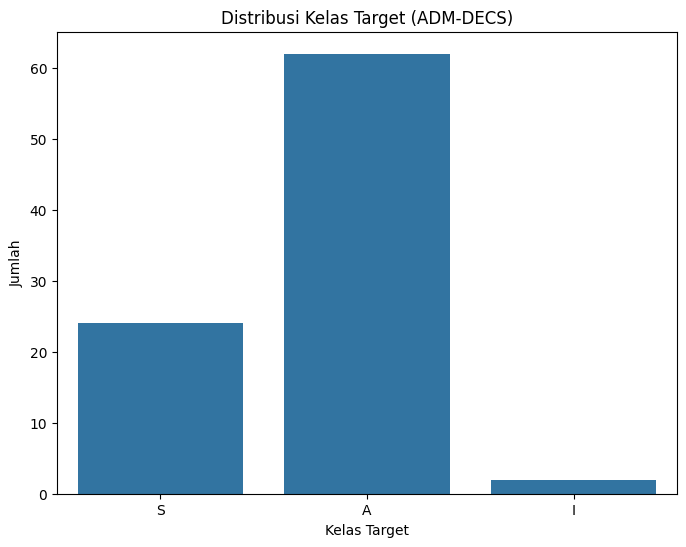

ADM-DECS
A    62
S    24
I     2
Name: count, dtype: int64


In [ ]:
# prompt: Melihat Distribusi Kelas Target

# Melihat Distribusi Kelas Target
plt.figure(figsize=(8, 6))
sns.countplot(x='ADM-DECS', data=df)
plt.title('Distribusi Kelas Target (ADM-DECS)')
plt.xlabel('Kelas Target')
plt.ylabel('Jumlah')
plt.show()

print(df['ADM-DECS'].value_counts())

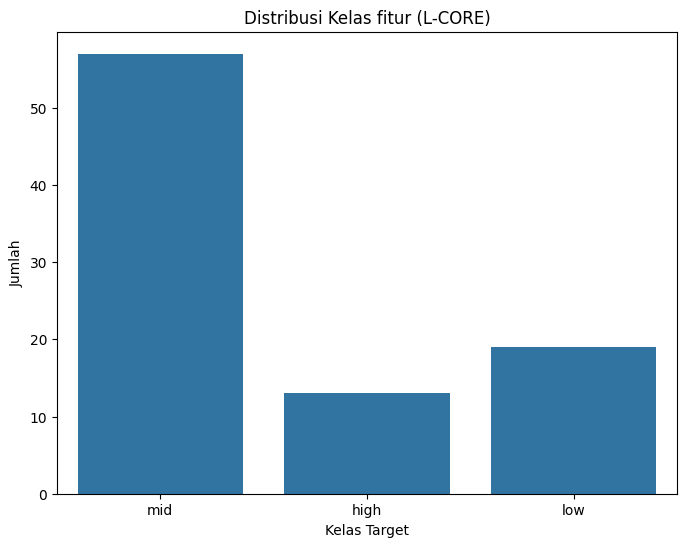

L-CORE
mid     57
low     19
high    13
Name: count, dtype: int64


In [ ]:
# prompt: Melihat Distribusi Kelas fitur

import matplotlib.pyplot as plt
import seaborn as sns

# Melihat Distribusi Kelas Target
plt.figure(figsize=(8, 6))
sns.countplot(x='L-CORE', data=df)
plt.title('Distribusi Kelas fitur (L-CORE)')
plt.xlabel('Kelas Target')
plt.ylabel('Jumlah')
plt.show()

print(df['L-CORE'].value_counts())

Count Plot menunjukkan ketidakseimbangan target(kelas) dalam data.

Diagram tersebut menunjukkan dataset akan cenderung memberikan akurasi klasifikasi yang buruk karena bisa saja akurasi trainingnya tinggi, namun akurasi testingnya rendah.
Parameter yang akan memberikan knowladge yang lebih baik:
1. Confussion Matrix
2. Precission
3. Recall
4. F1 Score

# 4.) Menentukan Object Data
Menentukan feature: Kolom mana saja yang akan digunakan untuk pemodelan.

Gunakan `.drop` untuk menghapus.

Kolom pertama merupakan kolom ID pasien yang tidak diperlukan untuk melatih model.

- Identifikasi Kolom 'Unnamed' (opsional) `print(df.columns)`


Metode:
- Menghapus Kolom Berdasarkan Nama `df.drop(columns=['Unnamed: 0'])`
- Menghapus Kolom Berdasarkan Indeks `df.drop(df.columns[0], axis=1, inplace=True)` atau `df = df.drop(df.columns[0], axis=1)`
- Menghapus Semua Kolom 'Unnamed' Secara Otomatis `df = df.loc[:, ~df.columns.str.contains('^Unnamed')]`
- Mengabaikan Kolom 'Unnamed' Saat Membaca File `df = pd.read_csv('file.csv', index_col=0)`

In [ ]:
# Pastikan hasil penghapusan kolom
df.head()

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,1,mid,high,excellent,high,stable,stable,stable,10,S
1,2,high,low,excellent,high,stable,stable,mod-stable,10,A
2,3,mid,low,good,high,stable,unstable,mod-stable,15,A
3,4,mid,mid,excellent,high,stable,stable,stable,10,A
4,5,high,low,good,mid,NaN,stable,unstable,15,S


## Membagi dataset berdasarkan tipe data

In [ ]:
# Membagi kolom bertipe kategorikal dan numerik
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [ ]:
# Pastikan dimensi setelah penghapusan feature
df.shape

(89, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PATIENT_NUMBER  89 non-null     int64 
 1   L-CORE          89 non-null     object
 2   L-SURF          89 non-null     object
 3   L-O2            80 non-null     object
 4   L-BP            89 non-null     object
 5   SURF-STBL       80 non-null     object
 6   CORE-STBL       89 non-null     object
 7   BP-STBL         89 non-null     object
 8   COMFORT         80 non-null     object
 9   ADM-DECS        88 non-null     object
dtypes: int64(1), object(9)
memory usage: 7.1+ KB


# 5.) Membersihkan Data

Karena ditemukan missing value pada dataset, perlu dilakukan handling missing value agar data bisa diolah dengan baik.

Cara:
- Menghapus missing value
- Mengisi missing value dengan nilai tertentu

In [ ]:
# # Hapus berdasarkan Index
# df.drop(df.columns[0], axis=1, inplace=True)

## Jumlah Missing Value

In [ ]:
# Tampilkan jumlah missing value di setiap kolom.
df.isna().sum().sort_values(ascending = False)

,0
L-O2,9
SURF-STBL,9
COMFORT,9
ADM-DECS,1
PATIENT_NUMBER,0
L-CORE,0
L-SURF,0
L-BP,0
CORE-STBL,0
BP-STBL,0


### Kolom Numerik

In [ ]:
# Periksa missing value pada kolom numerik yang tercantum dalam num_cols
df[num_cols].isnull().sum()

,0
PATIENT_NUMBER,0


tidak Terdapat missing value pada kolom bertipe numerik

### Kolom Kategorikal

In [ ]:
# Periksa missing value pada kolom kategori yang tercantum dalam cat_cols
df[cat_cols].isnull().sum()

,0
L-CORE,0
L-SURF,0
L-O2,9
L-BP,0
SURF-STBL,9
CORE-STBL,0
BP-STBL,0
COMFORT,9
ADM-DECS,1


terdapat missing value pada kolom bertipe kategorikal

## soal no 5 Handling Missing Value

Metode:

*   Random Value Imputation: Mengisi missing value dengan sampel acak dari nilai non-null di kolom yang sama. Digunakan untuk kolom dengan banyak nilai hilang. Random Value Imputation bertujuan untuk mempertahankan variasi dalam data.
*   Mean/Mode Imputation: Mengisi missing value dengan rata-rata (mean) untuk data numerik atau modus (mode) untuk data kategorikal. Digunakan untuk kolom dengan sedikit nilai hilang.

Karena kolom yang memiliki missing value bertipe numerik, maka lakukan imputasi dengan mean.

### Imputasi Numerik

In [ ]:
# # Daftar kolom yang memiliki missing value
# columns_with_missing = ['']

# # Imputasi missing value menggunakan mean
# for col in columns_with_missing:
#     df[col].fillna(df[col].mean(), inplace=True)

### Verifikasi Imputasi

In [ ]:
# # Verifikasi apakah missing value sudah terisi
# print(df[columns_with_missing].isnull().sum())

Semua kalom yang sebelumnya memiliki missing value sudah tidak memiliki missing value lagi

### Imputasi Kategorikal

In [ ]:
# # Imputasi missing value pada kolom 'Sex' (kategorikal) menggunakan modus
# df['Sex'].fillna(df['Sex'].mode()[0], inplace=True)

# # Daftar kolom yang memiliki missing value
columns_with_missing = ['L-O2', 'SURF-STBL', 'COMFORT','ADM-DECS']

# Imputasi missing value menggunakan mode


for col in columns_with_missing:
    modes = df[col].mode() #modulus
    if not modes.empty:  # Memastikan mode ditemukan
        mode = np.random.choice(modes) # Memilih mode secara acak
        df[col].fillna(mode, inplace=True)

<ipython-input-31-189047713f43>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode, inplace=True)


### Verifikasi Imputasi

In [ ]:
# Verifikasi apakah missing value sudah terisi
print(df[columns_with_missing].isnull().sum())

L-O2         0
SURF-STBL    0
COMFORT      0
ADM-DECS     0
dtype: int64


### Periksa Hasil Imputasi

In [ ]:
# Periksa informasi jumlah Non-Null apakah sudah sama
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PATIENT_NUMBER  89 non-null     int64 
 1   L-CORE          89 non-null     object
 2   L-SURF          89 non-null     object
 3   L-O2            89 non-null     object
 4   L-BP            89 non-null     object
 5   SURF-STBL       89 non-null     object
 6   CORE-STBL       89 non-null     object
 7   BP-STBL         89 non-null     object
 8   COMFORT         89 non-null     object
 9   ADM-DECS        89 non-null     object
dtypes: int64(1), object(9)
memory usage: 7.1+ KB


## Handling Duplikat Data (soal no 6)

Metode:

* Menampilkan 1 data dari masing-masing data duplikat `duplicates = df[df.duplicated()]`
* Menimpilkan semua data duplikat `all_duplicates = df[df.duplicated(keep=False)]`

In [ ]:
# Perika jumlah baris duplikat
df.duplicated().sum()

0

In [ ]:
df.isna().sum()

,0
PATIENT_NUMBER,0
L-CORE,0
L-SURF,0
L-O2,0
L-BP,0
SURF-STBL,0
CORE-STBL,0
BP-STBL,0
COMFORT,0
ADM-DECS,0


In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
# Tampilkan data duplikat
duplicates = df[df.duplicated(keep=False)]
duplicates

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS


Tidak ada data duplikat pada dataset

## Mengonversi Tipe Data (Label Encoding)
Label Encoding adalah proses mengubah data kategorikal (berupa teks atau string) menjadi nilai numerik yang unik untuk setiap kategori. Metode ini sering digunakan sebagai langkah preprocessing untuk data kategorikal agar dapat digunakan oleh algoritma pembelajaran mesin.

In [ ]:
# Tampilkan jumlah kategori unik pada setiap kolom kategori
for col in cat_cols:
    print(f"{col} has {df[col].nunique()} categories\n")

L-CORE has 3 categories

L-SURF has 3 categories

L-O2 has 2 categories

L-BP has 3 categories

SURF-STBL has 2 categories

CORE-STBL has 3 categories

BP-STBL has 3 categories

COMFORT has 5 categories

ADM-DECS has 3 categories



In [ ]:
# Periksa kembali dataset
df.head()

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,1,mid,high,excellent,high,stable,stable,stable,10,S
1,2,high,low,excellent,high,stable,stable,mod-stable,10,A
2,3,mid,low,good,high,stable,unstable,mod-stable,15,A
3,4,mid,mid,excellent,high,stable,stable,stable,10,A
4,5,high,low,good,mid,stable,stable,unstable,15,S


### Import Library

In [ ]:
# Import LabelEncoder
# LabelEncoder: Salah satu metode dari sklearn untuk mengubah data kategori menjadi angka seperti 0, 1, 2 dst
from sklearn.preprocessing import LabelEncoder

### Proses Encoding (8)

In [ ]:
# Inisialisasi Label Encoder
le = LabelEncoder()

# Lakukan Encoding pada kolom Kategori (mengubah kategori menjadi angka unik)
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

### Periksa Hasil Encoding

In [ ]:
# Tampilkan informasi kolom dan memori
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   PATIENT_NUMBER  89 non-null     int64
 1   L-CORE          89 non-null     int64
 2   L-SURF          89 non-null     int64
 3   L-O2            89 non-null     int64
 4   L-BP            89 non-null     int64
 5   SURF-STBL       89 non-null     int64
 6   CORE-STBL       89 non-null     int64
 7   BP-STBL         89 non-null     int64
 8   COMFORT         89 non-null     int64
 9   ADM-DECS        89 non-null     int64
dtypes: int64(10)
memory usage: 7.1 KB


In [ ]:
# Tampilkan bentuk dataset setelah label encoding
df.head()

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,1,2,0,0,0,0,1,1,2,2
1,2,0,1,0,0,0,1,0,2,0
2,3,2,1,1,0,0,2,0,3,0
3,4,2,2,0,0,0,1,1,2,0
4,5,0,1,1,2,0,1,2,3,2


## Deteksi Outliers

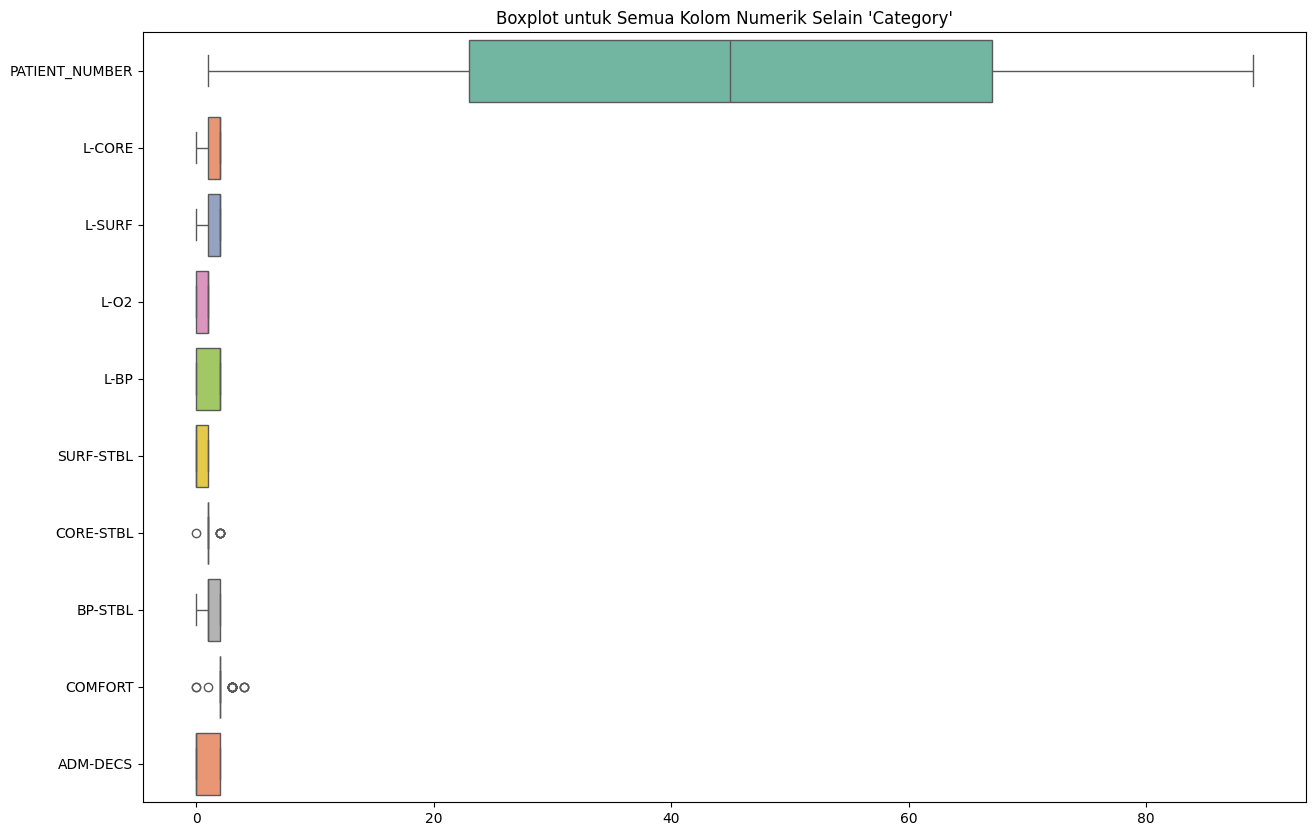

In [ ]:
# Pilih hanya kolom numerik selain kolom Target
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = numerical_cols[numerical_cols != 'Category']  # Menghapus kolom 'Category'

# Buat boxplot untuk setiap kolom numerik selain 'Category'
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numerical_cols], orient='h', palette="Set2")
plt.title("Boxplot untuk Semua Kolom Numerik Selain 'Category'")
plt.show()

Menghapus outlier bukanlah keputusan yang mudah karena bisa jadi memberi pengaruh buruk pada analisis atau model. Meskipun terkadang menghapus outlier dapat menghasilkan statistik atau model yang lebih baik, tetap saja ada risiko overfitting, yaitu model terlalu terfokus pada data yang tersisa dan tidak dapat bekerja baik pada data baru.

### Handling Outliers

In [ ]:
df_iqr = df.copy() # Buat copy dataset asli
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if col not in []:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Ganti outliers dengan batas bawah/atas
        df_iqr[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
        print(f"Outliers pada kolom '{col}' telah ditangani menggunakan metode IQR.")

Outliers pada kolom 'PATIENT_NUMBER' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'L-CORE' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'L-SURF' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'L-O2' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'L-BP' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'SURF-STBL' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'CORE-STBL' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'BP-STBL' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'COMFORT' telah ditangani menggunakan metode IQR.
Outliers pada kolom 'ADM-DECS' telah ditangani menggunakan metode IQR.


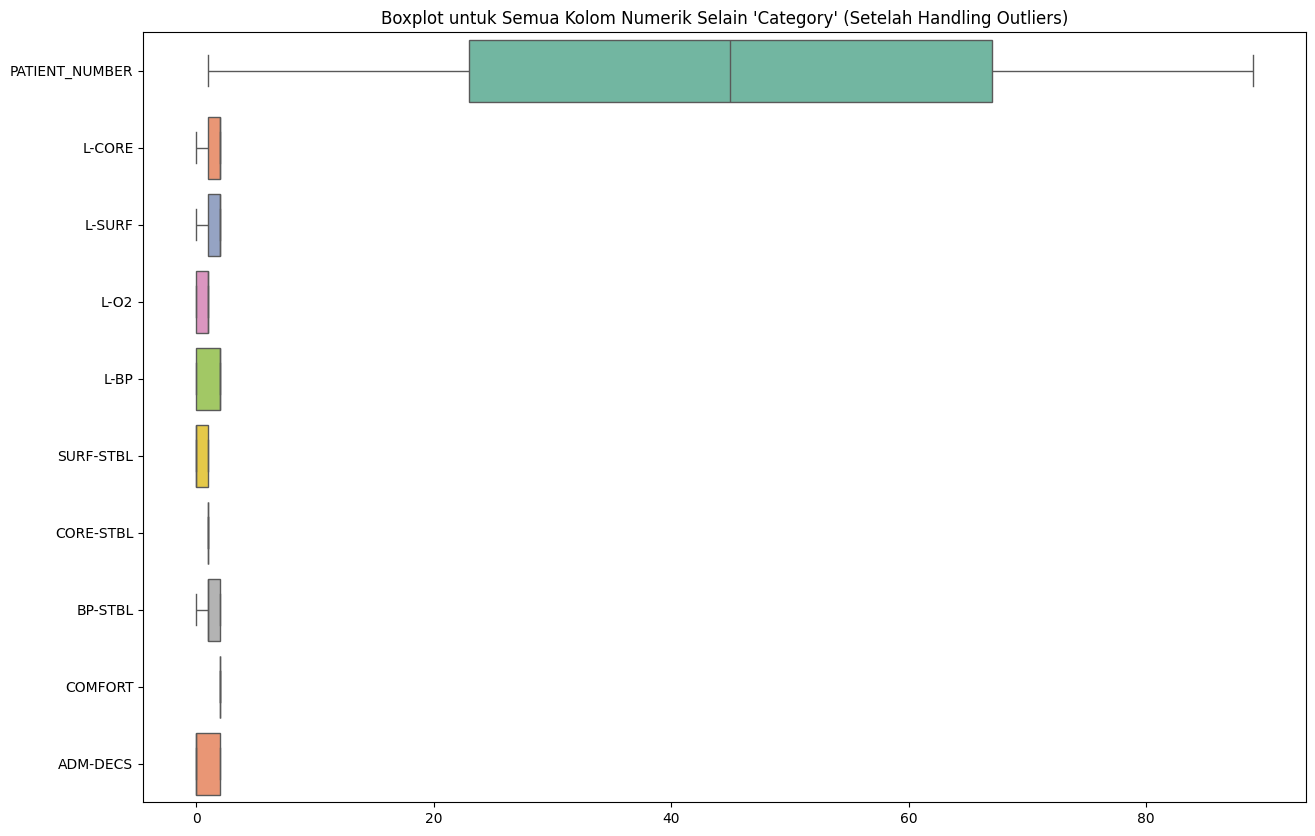

In [ ]:
# Pilih hanya kolom numerik selain kolom target
numerical_cols = df_iqr.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = numerical_cols[numerical_cols != 'Category']  # Menghapus kolom 'Category'

# Buat boxplot untuk setiap kolom numerik selain 'Category'
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_iqr[numerical_cols], orient='h', palette="Set2")
plt.title("Boxplot untuk Semua Kolom Numerik Selain 'Category' (Setelah Handling Outliers)")
plt.show()

In [ ]:
df.isna().sum().sort_values(ascending = False)

,0
PATIENT_NUMBER,0
L-CORE,0
L-SURF,0
L-O2,0
L-BP,0
SURF-STBL,0
CORE-STBL,0
BP-STBL,0
COMFORT,0
ADM-DECS,0


# 6.) Konstruksi Data

## Handling Imbalance Data

### Import Library

In [ ]:
# Import Library yang dibutuhkan untuk handling imbalance
# Menggunakan metode oversampling
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
# Memisahkan kolom feature dan kolom target
X = df_iqr.drop("ADM-DECS",axis=1).values
y = df_iqr['ADM-DECS']

In [ ]:
# Split data untuk training dan testing
# Remove stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Oversampling menggunakan RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_over, y_over = oversample.fit_resample(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
# Tampilkan distribusi kelas
"Distribusi kelas setelah oversampling:", Counter(y_over)

('Distribusi kelas setelah oversampling:', Counter({0: 47, 2: 47, 1: 47}))

### Visualisasi Sebelum dan sesudah Handling

<ipython-input-53-f91941c3a5c6>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


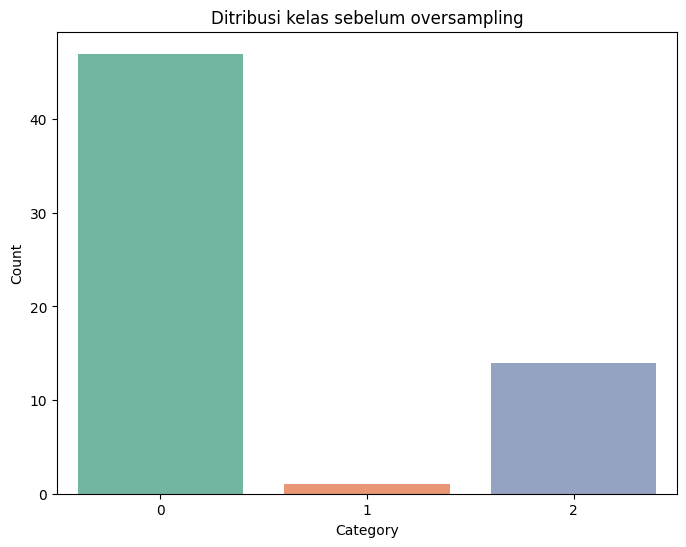

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
<ipython-input-53-f91941c3a5c6>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_over, palette="Set2")


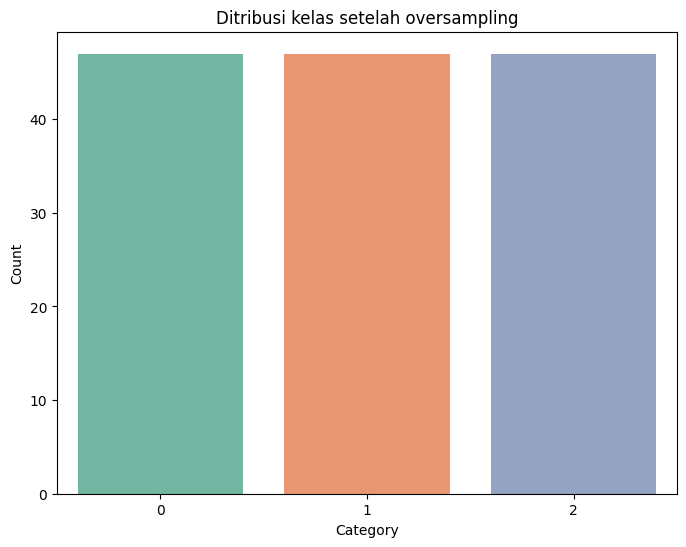

In [ ]:
# Visualisasi distribusi kelas sebelum handling imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette="Set2")
plt.title("Ditribusi kelas sebelum oversampling")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Oversampling menggunakan RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_over, y_over = oversample.fit_resample(X_train, y_train)

# Visualisasi distribusi kelas setelah oversampling
plt.figure(figsize=(8, 6))
sns.countplot(x=y_over, palette="Set2")
plt.title("Ditribusi kelas setelah oversampling")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## Melihat Hasil Handling Imbalance

In [ ]:
oversampled_df = pd.DataFrame(X_over, columns=df_iqr.drop("ADM-DECS", axis=1).columns)
oversampled_df['ADM-DECS'] = y_over

# Tampilkan dataset setelah oversampling
oversampled_df

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,10.0,2.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,0
1,68.0,2.0,2.0,1.0,0.0,0.0,1.0,1.0,2.0,0
2,6.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,2
3,76.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,0
4,41.0,1.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,2
...,...,...,...,...,...,...,...,...,...,...
136,14.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,2
137,6.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,2
138,53.0,2.0,2.0,1.0,2.0,1.0,1.0,0.0,2.0,2
139,42.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,2


## Korelasi (9)

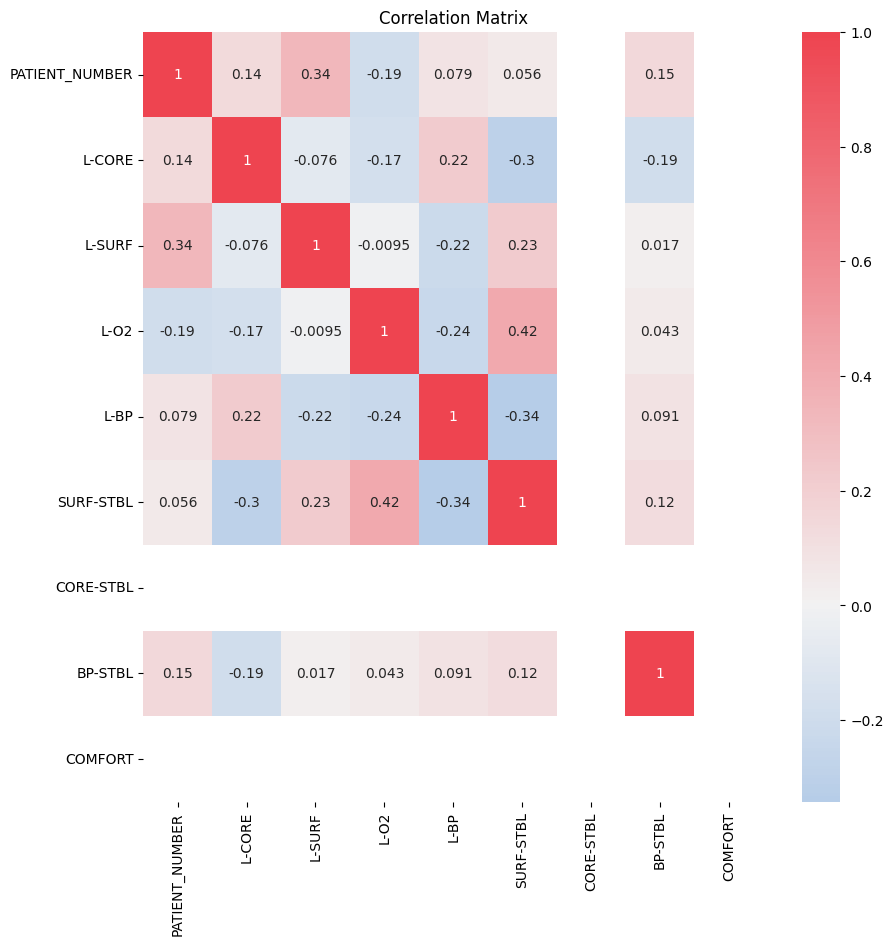

In [ ]:
corrmat = oversampled_df.drop(columns=["ADM-DECS"]).corr()
plt.figure(figsize=(10, 10))

# Beri warna
cmap = sns.diverging_palette(250, 10, s=80, l=55, n=9, as_cmap=True)

# Plot
sns.heatmap(corrmat, annot=True, cmap=cmap, center=0)
plt.title("Correlation Matrix")
plt.show()

## Hasil Akhir Pembersihan Data

### Visualisasi fitur (no 7)

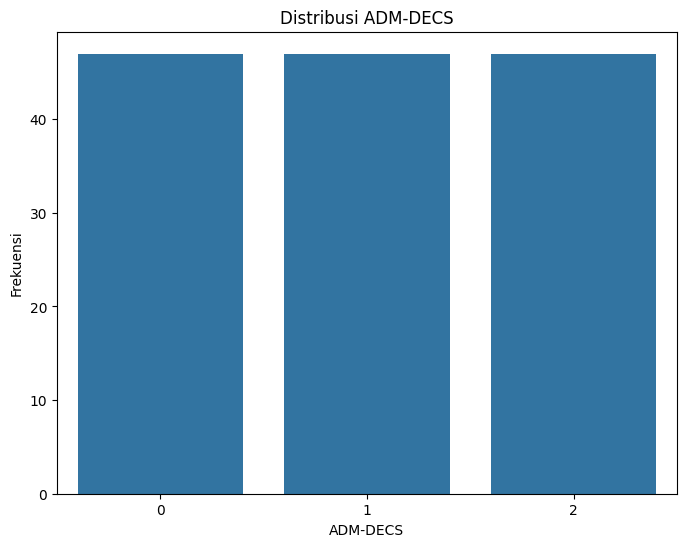

In [ ]:
# Buat bar chart untuk kolom 'Category'
plt.figure(figsize=(8, 6))
sns.countplot(data=oversampled_df, x='ADM-DECS')
plt.title('Distribusi ADM-DECS')
plt.xlabel('ADM-DECS')
plt.ylabel('Frekuensi')
plt.show()

<ipython-input-57-bfb27d72f76e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col].value_counts().index, y=df[col].value_counts(), palette=clr)
<ipython-input-57-bfb27d72f76e>:6: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(x=df[col].value_counts().index, y=df[col].value_counts(), palette=clr)
<ipython-input-57-bfb27d72f76e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col].value_counts().index, y=df[col].value_counts(), palette=clr)
<ipython-input-57-bfb27d72f76e>:6: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(x=df[col].value_counts().index, y=df[

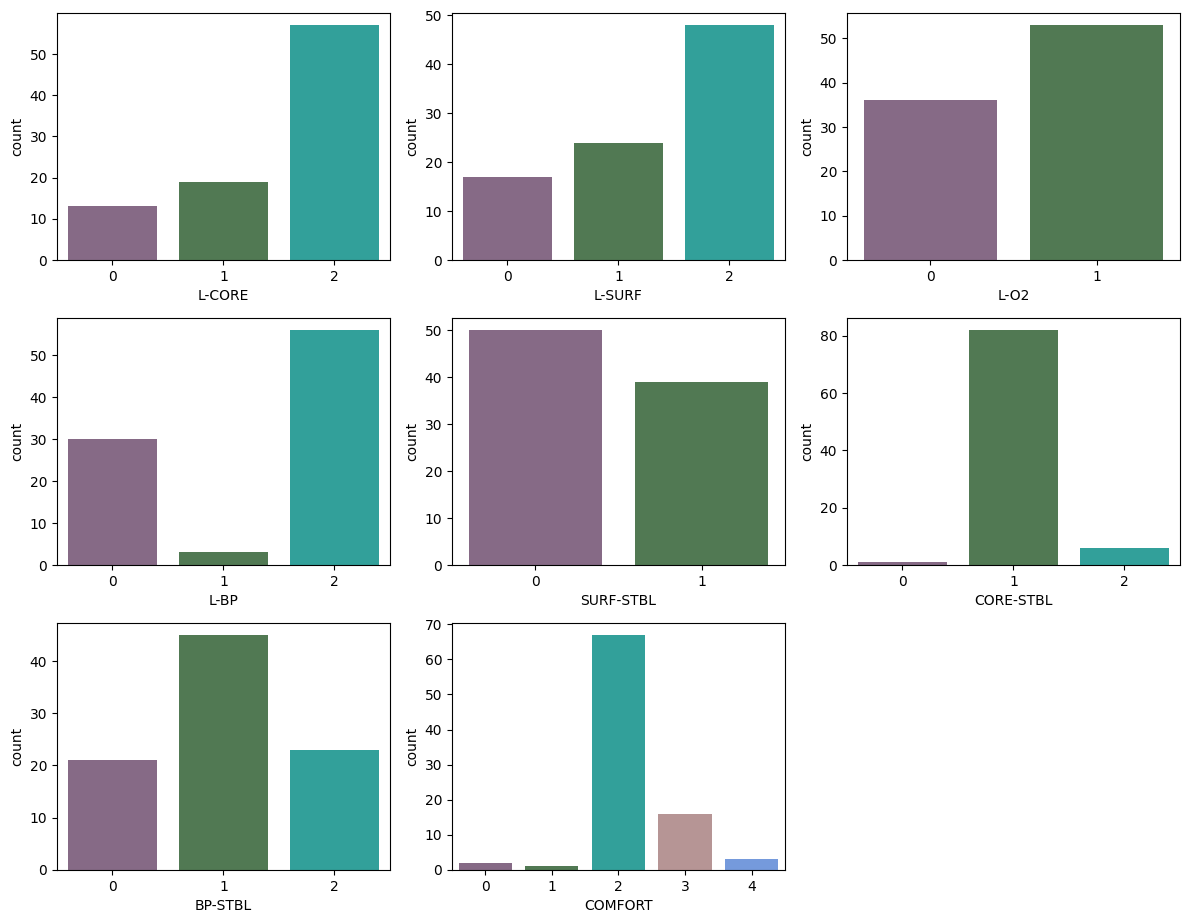

In [ ]:
cat_cols = ["L-CORE", "L-SURF", "L-O2", "L-BP", "SURF-STBL", "CORE-STBL", "BP-STBL", "COMFORT"] # Updated column names to reflect changes made with data.rename
clr = ["#8b658b", "#4a804d", "#20b2aa", "#bc8f8f", "#6495ed", "#FFA07A", "#FA8072", "#E9967A"]
plt.figure(figsize=(12,15))
for i, col in enumerate(cat_cols):
    plt.subplot(5,3, i+1)
    sns.barplot(x=df[col].value_counts().index, y=df[col].value_counts(), palette=clr)
plt.tight_layout()
plt.show()

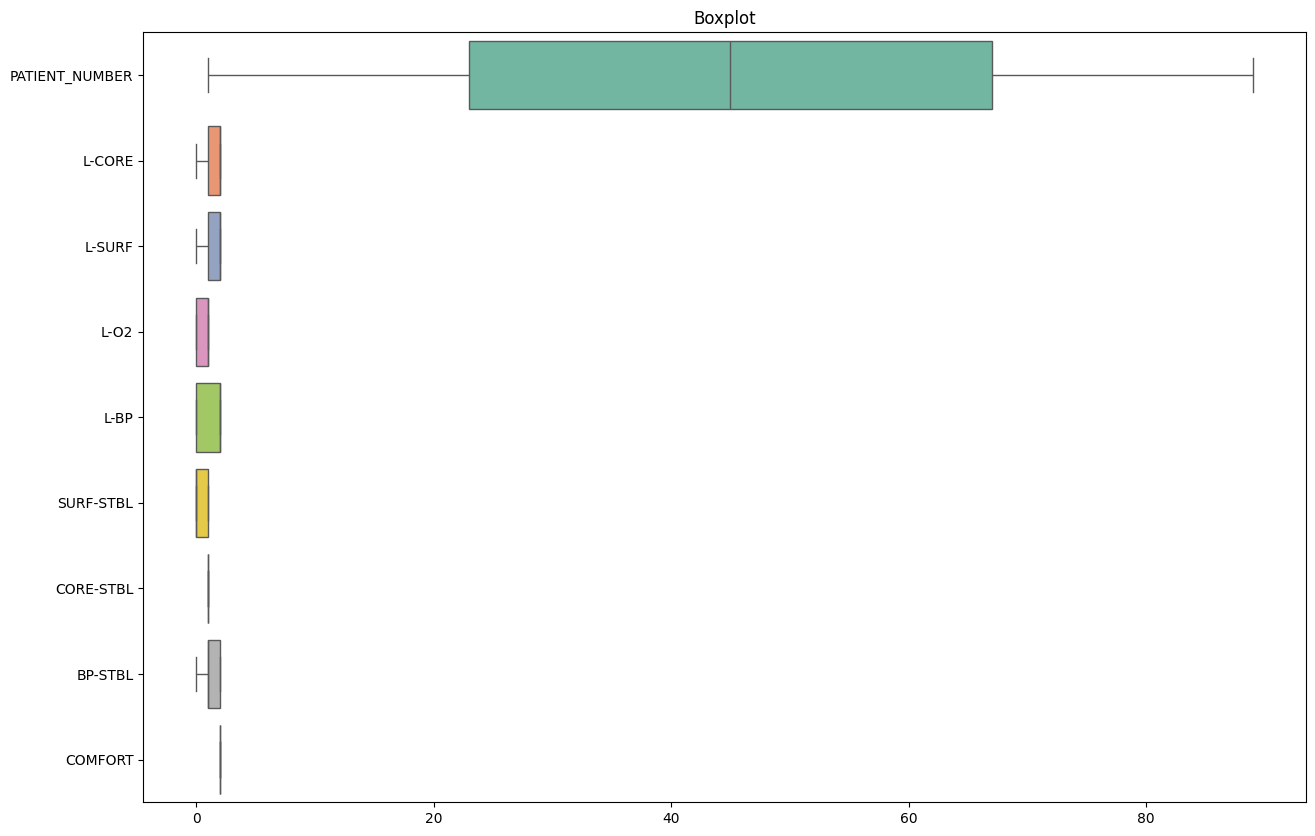

In [ ]:
# # Pilih hanya kolom numerik selain kolom Target
numerical_cols = oversampled_df.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = numerical_cols[numerical_cols != 'ADM-DECS']  # Menghapus kolom 'Category'

# Buat boxplot untuk setiap kolom numerik selain 'Category'
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_iqr[numerical_cols], orient='h', palette="Set2")
plt.title("Boxplot")
plt.show()

### Tabel Data

In [ ]:
# Dataset setelah proses cleaning
oversampled_df

,PATIENT_NUMBER,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,10.0,2.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,0
1,68.0,2.0,2.0,1.0,0.0,0.0,1.0,1.0,2.0,0
2,6.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,2
3,76.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,0
4,41.0,1.0,2.0,1.0,2.0,0.0,1.0,1.0,2.0,2
...,...,...,...,...,...,...,...,...,...,...
136,14.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,2
137,6.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,2
138,53.0,2.0,2.0,1.0,2.0,1.0,1.0,0.0,2.0,2
139,42.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,2


Semua missing value sudah diimputasi dan semua feature sudah bertipe data numerik

# 7.) Menentukan Label Data

## Import Library

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

## Splitting Data (no 10 and 11)

In [ ]:
# Memisahkan kolom feature dan kolom target
X = oversampled_df.drop("ADM-DECS",axis=1).values
y = oversampled_df['ADM-DECS']

In [ ]:
# Split data dengan perbandingan data training dan data testing adalah 70 : 30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# scaler = MinMaxScaler()

# # Fit dan transform data training
# X_train_scaled = scaler.fit_transform(X_train)

# # Transform data testing
# X_test_scaled = scaler.transform(X_test)

`train_test_split` adalah metode yang disediakan Sckit-learn yang berguna untuk membagi array atau matriks menjadi data training dan data testing secara acak https://www.geeksforgeeks.org/how-to-split-the-dataset-with-scikit-learns-train_test_split-function/.

# 8.) Membangun dan Mengevaluasi Model

## Import Library

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

## Insialisasi Model

In [ ]:
# Inisialisasi
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)
svm = SVC(random_state=42)
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()

models = {
    "Naive Bayes": nb,
    "Random Forest": rf,
    "SVM": svm,
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "K-Nearest Neighbors": knn,

}


# dt = DecisionTreeClassifier(random_state=42)

# models = {
#     "Decision Tree": dt,
# }

## Melatih Model

### Naive Bayes

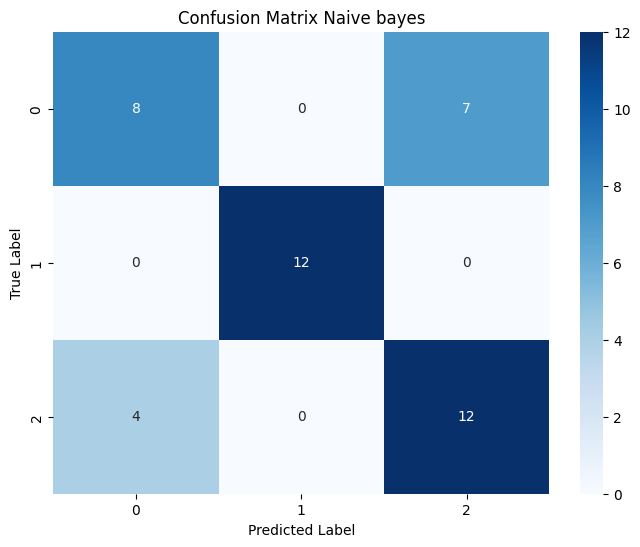

              precision    recall  f1-score   support

           0       0.67      0.53      0.59        15
           1       1.00      1.00      1.00        12
           2       0.63      0.75      0.69        16

    accuracy                           0.74        43
   macro avg       0.77      0.76      0.76        43
weighted avg       0.75      0.74      0.74        43



In [ ]:
nb.fit(X_train, y_train)

nb_y_pred = nb.predict(X_test)
accuracy_nb = round(accuracy_score(y_test, nb_y_pred), 3)

cm = confusion_matrix(y_test, nb_y_pred)

# Generate a clear and informative confusion matrix plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Naive bayes")
plt.show()

print(classification_report(y_test, nb_y_pred))

### Random Forest

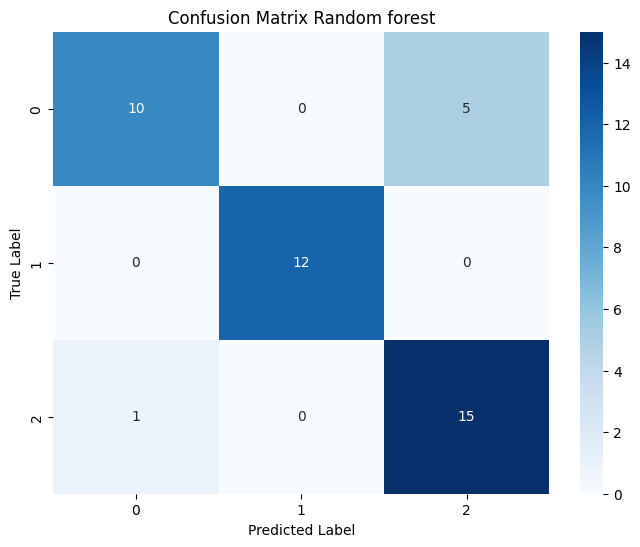

              precision    recall  f1-score   support

           0       0.91      0.67      0.77        15
           1       1.00      1.00      1.00        12
           2       0.75      0.94      0.83        16

    accuracy                           0.86        43
   macro avg       0.89      0.87      0.87        43
weighted avg       0.88      0.86      0.86        43



In [ ]:
rf.fit(X_train, y_train)

rf_y_pred = rf.predict(X_test)
accuracy_rf = round(accuracy_score(y_test, rf_y_pred), 3)

cm = confusion_matrix(y_test, rf_y_pred)

# Generate a clear and informative confusion matrix plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Random forest")
plt.show()

print(classification_report(y_test, rf_y_pred))

### SVM

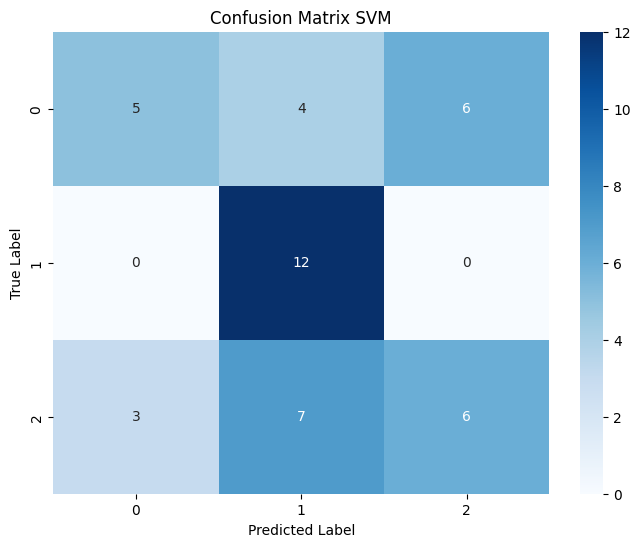

              precision    recall  f1-score   support

           0       0.62      0.33      0.43        15
           1       0.52      1.00      0.69        12
           2       0.50      0.38      0.43        16

    accuracy                           0.53        43
   macro avg       0.55      0.57      0.52        43
weighted avg       0.55      0.53      0.50        43



In [ ]:
svm.fit(X_train, y_train)

svm_y_pred = svm.predict(X_test)
accuracy_svm = round(accuracy_score(y_test, svm_y_pred), 3)

cm = confusion_matrix(y_test, svm_y_pred)

# Generate a clear and informative confusion matrix plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix SVM")
plt.show()

print(classification_report(y_test, svm_y_pred))

### Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


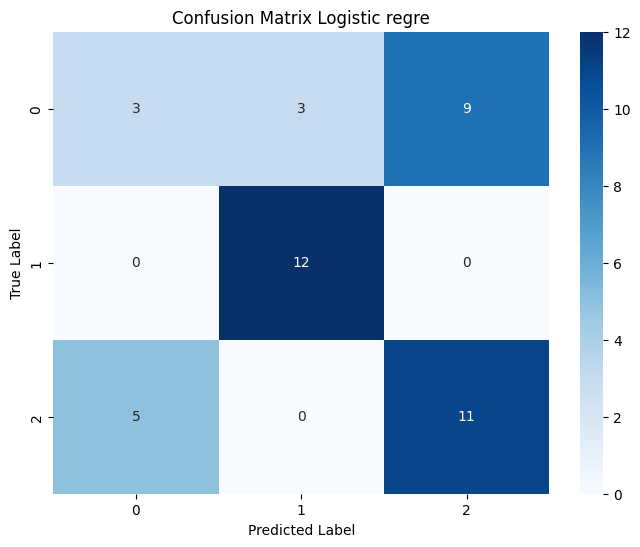

              precision    recall  f1-score   support

           0       0.38      0.20      0.26        15
           1       0.80      1.00      0.89        12
           2       0.55      0.69      0.61        16

    accuracy                           0.60        43
   macro avg       0.58      0.63      0.59        43
weighted avg       0.56      0.60      0.57        43



In [ ]:
lr.fit(X_train, y_train)

lr_y_pred = lr.predict(X_test)
accuracy_lr = round(accuracy_score(y_test, lr_y_pred), 3)

cm = confusion_matrix(y_test, lr_y_pred)

# Generate a clear and informative confusion matrix plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Logistic regre")
plt.show()

print(classification_report(y_test, lr_y_pred))

### Decision Tree

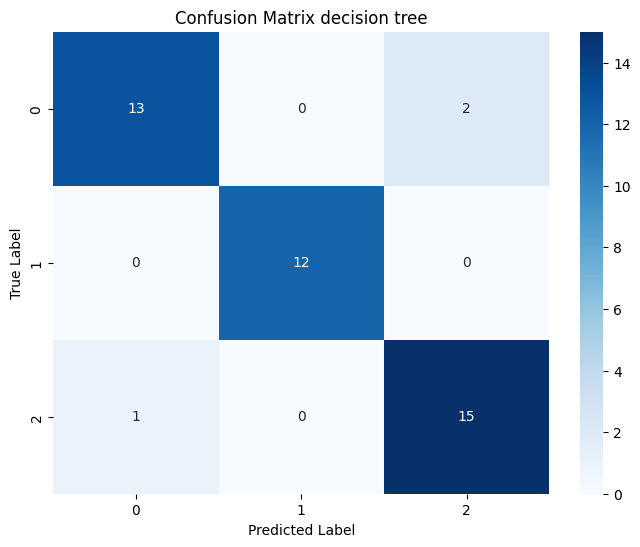

              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       1.00      1.00      1.00        12
           2       0.88      0.94      0.91        16

    accuracy                           0.93        43
   macro avg       0.94      0.93      0.94        43
weighted avg       0.93      0.93      0.93        43



In [ ]:
dt.fit(X_train, y_train)
dt_y_pred = dt.predict(X_test)
accuracy_dt = round(accuracy_score(y_test, dt_y_pred), 3)

cm = confusion_matrix(y_test, dt_y_pred)

# Generate a clear and informative confusion matrix plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix decision tree")
plt.show()
print(classification_report(y_test, dt_y_pred))

### K-Nearest Neighbor

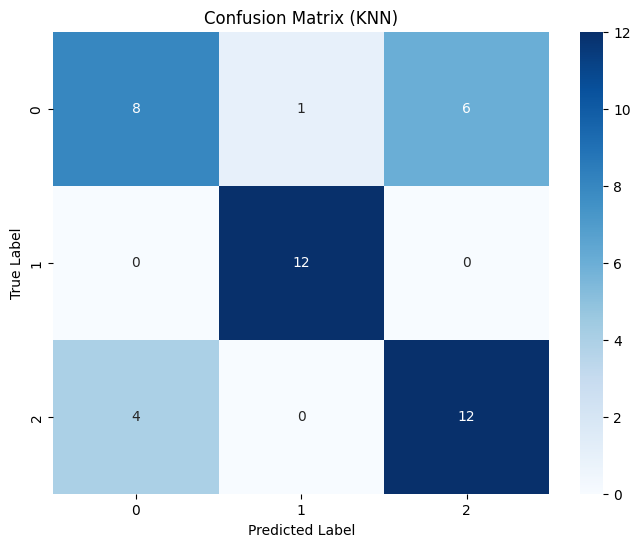

              precision    recall  f1-score   support

           0       0.67      0.53      0.59        15
           1       0.92      1.00      0.96        12
           2       0.67      0.75      0.71        16

    accuracy                           0.74        43
   macro avg       0.75      0.76      0.75        43
weighted avg       0.74      0.74      0.74        43



In [ ]:
knn.fit(X_train, y_train)

knn_y_pred = knn.predict(X_test)
accuracy_knn = round(accuracy_score(y_test, knn_y_pred), 3)

cm = confusion_matrix(y_test, knn_y_pred)

# Generate a clear and informative confusion matrix plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (KNN)")
plt.show()
print(classification_report(y_test, knn_y_pred))

### optimasi model pada decision tree

In [ ]:
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(
#     max_depth=6,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     random_state=42
# )
# dt.fit(X_train, y_train)
# dt_y_pred = dt.predict(X_test)
# accuracy_dt = round(accuracy_score(y_test, dt_y_pred), 3)
# cm = confusion_matrix(y_test, dt_y_pred)

# # Generate a clear and informative confusion matrix plot using Seaborn
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")  # Customize formatting
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix (DecisionTree)")
# plt.show()
# print(classification_report(y_test, dt_y_pred))

# 9.) Komparasi Model

<ipython-input-73-8d21a3d1b237>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


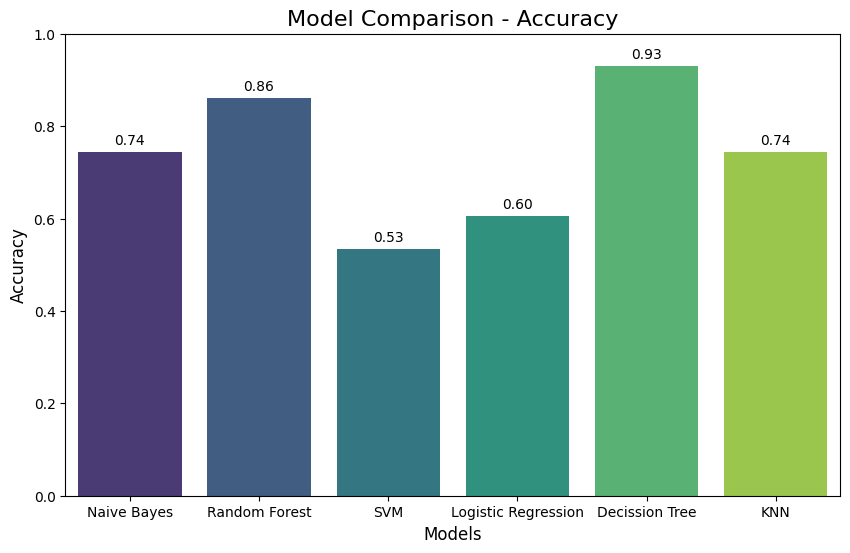

In [ ]:
models = ['Naive Bayes', 'Random Forest', 'SVM', 'Logistic Regression', 'Decission Tree', 'KNN']
accuracies = [
    accuracy_score(y_test, nb_y_pred),
    accuracy_score(y_test, rf_y_pred),
    accuracy_score(y_test, svm_y_pred),
    accuracy_score(y_test, lr_y_pred),
    accuracy_score(y_test, dt_y_pred),
    accuracy_score(y_test, knn_y_pred)
]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.title('Model Comparison - Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim(0, 1)
plt.show()

# models = ['Decission Tree']
# accuracies = [
#     accuracy_score(y_test, dt_y_pred),
# ]
# plt.figure(figsize=(10, 6))
# sns.barplot(x=models, y=accuracies, palette='viridis')
# for i, acc in enumerate(accuracies):
#     plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=10, color='black')
# plt.title('Model Comparison - Accuracy', fontsize=16)
# plt.ylabel('Accuracy', fontsize=12)
# plt.xlabel('Models', fontsize=12)
# plt.ylim(0, 1)
# plt.show()

In [ ]:
# df.drop_duplicates(inplace = True)
# # Inisialisasi
# dt = DecisionTreeClassifier(random_state=42)

# models = {
#     "Decision Tree": dt,
# }

# dt.fit(X_train, y_train)
# dt_y_pred = dt.predict(X_test)
# accuracy_dt = round(accuracy_score(y_test, dt_y_pred), 3)
# print(confusion_matrix(y_test, dt_y_pred))
# print(classification_report(y_test, dt_y_pred))